In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/happines_corruption.csv')

* Country - Name of the country.
* happiness_score - Average of responses to the primary life evaluation question from the Gallup World Poll (GWP). 0-10
* gdp_per_capita - The extent to which GDP contributes to the calculation of the Happiness Score.
* family - The extent to which Family contributes to the calculation of the Happiness Score
* health - The extent to which Life expectancy contributed to the calculation of the Happiness Score
* freedom - The extent to which Freedom contributed to the calculation of the Happiness Score
* generosity - A numerical value calculated based on poll participants’ perceptions of generosity in their country.
* government_trust - The extent to which Perception of Corruption contributes to Happiness Score.
* dystopia_residual - A score based on a hypothetical comparison to the world’s saddest country.
* continent - Region of the country.

In [ ]:
data.head()

,Country,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,continent,Year,social_support,cpi_score
0,Norway,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,Europe,2015,0.0,88
1,Denmark,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,Europe,2015,0.0,91
2,Iceland,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,Europe,2015,0.0,79
3,Switzerland,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,Europe,2015,0.0,86
4,Finland,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,Europe,2015,0.0,90


# Задание 1

* Базово изучите датасет (достаточно методов info() и describe()).
* Выдвиньте пару гипотез, например, “Верно ли, что чем выше ВВП, тем выше и уровень счастья?” или “Есть ли взаимосвязь между уровнем доверия правительству и уровнем счастья?”. Постарайтесь подтвердить или опровергнуть их визуально и с помощью расчётов.

**Желательно, но не обязательно:**
* Составьте корреляционную матрицу всех числовых признаков набора данных и визуализируйте её с помощью тепловой карты.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            792 non-null    object 
 1   happiness_score    792 non-null    float64
 2   gdp_per_capita     792 non-null    float64
 3   family             792 non-null    float64
 4   health             792 non-null    float64
 5   freedom            792 non-null    float64
 6   generosity         792 non-null    float64
 7   government_trust   792 non-null    float64
 8   dystopia_residual  792 non-null    float64
 9   continent          792 non-null    object 
 10  Year               792 non-null    int64  
 11  social_support     792 non-null    float64
 12  cpi_score          792 non-null    int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 80.6+ KB


In [ ]:
data.describe()

,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,Year,social_support,cpi_score
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000
mean,5.473310,0.929217,0.504998,0.648691,0.427016,0.212440,0.125720,1.379277,2017.500000,0.609302,44.327020
std,1.124726,0.385774,0.552736,0.232261,0.148003,0.121660,0.109032,1.075276,1.708904,0.640754,19.508833
min,2.566900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,0.000000,11.000000
25%,4.590750,0.644242,0.000000,0.510070,0.325433,0.125784,0.052862,0.000000,2016.000000,0.000000,30.000000
50%,5.485500,0.994544,0.000000,0.685397,0.439621,0.197000,0.089000,1.731948,2017.500000,0.176214,38.000000
75%,6.300500,1.228677,1.040410,0.815641,0.546280,0.273250,0.154250,2.236894,2019.000000,1.268250,57.000000
max,7.808700,2.096000,1.610574,1.141000,0.724000,0.838075,0.551910,3.602140,2020.000000,1.644000,91.000000


Text(0.5, 1.0, 'Взаимосвязь ВВП и щедрости')

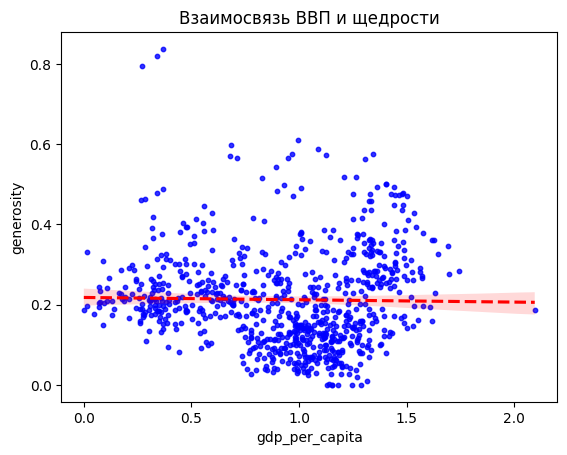

In [ ]:
# Гипотеза 1
# Чем выше ВВП, тем выше уровень щедрости

sns.regplot(
    data=data, x='gdp_per_capita', y='generosity',
    line_kws={'color': 'red', 'linestyle': '--'},  # Настройка линии
    scatter_kws={'color': 'blue', 's': 10},       # Настройка точек
    ci=95                                         # 95% доверительный интервал
)
plt.title('Взаимосвязь ВВП и щедрости')

In [ ]:
corr_coef = data['gdp_per_capita'].corr(data['generosity'])
print(f"Коэффициент корреляции: {corr_coef}")

Коэффициент корреляции: -0.018355213872667288


**Вывод**: Зависимость отсутствует или очень слабо выражена



Text(0.5, 1.0, 'Взаимосвязь уровня свобод и уровня счастья')

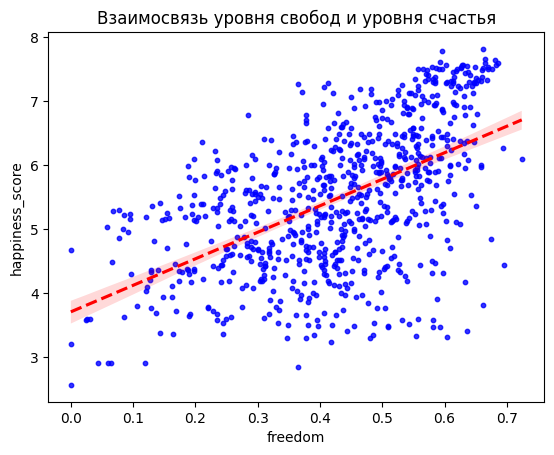

In [ ]:
# Гипотеза 2
# Чем выше уровень свобод, тем выше уровень счастья

sns.regplot(
    data=data, x='freedom', y='happiness_score',
    line_kws={'color': 'red', 'linestyle': '--'},  # Настройка линии
    scatter_kws={'color': 'blue', 's': 10},       # Настройка точек
    ci=95                                         # 95% доверительный интервал
)
plt.title('Взаимосвязь уровня свобод и уровня счастья')

In [ ]:
corr_coef = data['freedom'].corr(data['happiness_score'])
print(f"Коэффициент корреляции: {corr_coef}")

Коэффициент корреляции: 0.5442844089111075


**Вывод**: Наюлюдается завсимость средней силы

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Кодируем категориальные признаки для отображения полной матрицы корреляции
encoder = LabelEncoder()
data_numeric = data.copy()
data_numeric['continent'] = encoder.fit_transform(data['continent'])
data_numeric['Country'] = encoder.fit_transform(data['Country'])

Text(0.5, 1.0, 'Корреляционная матрица')

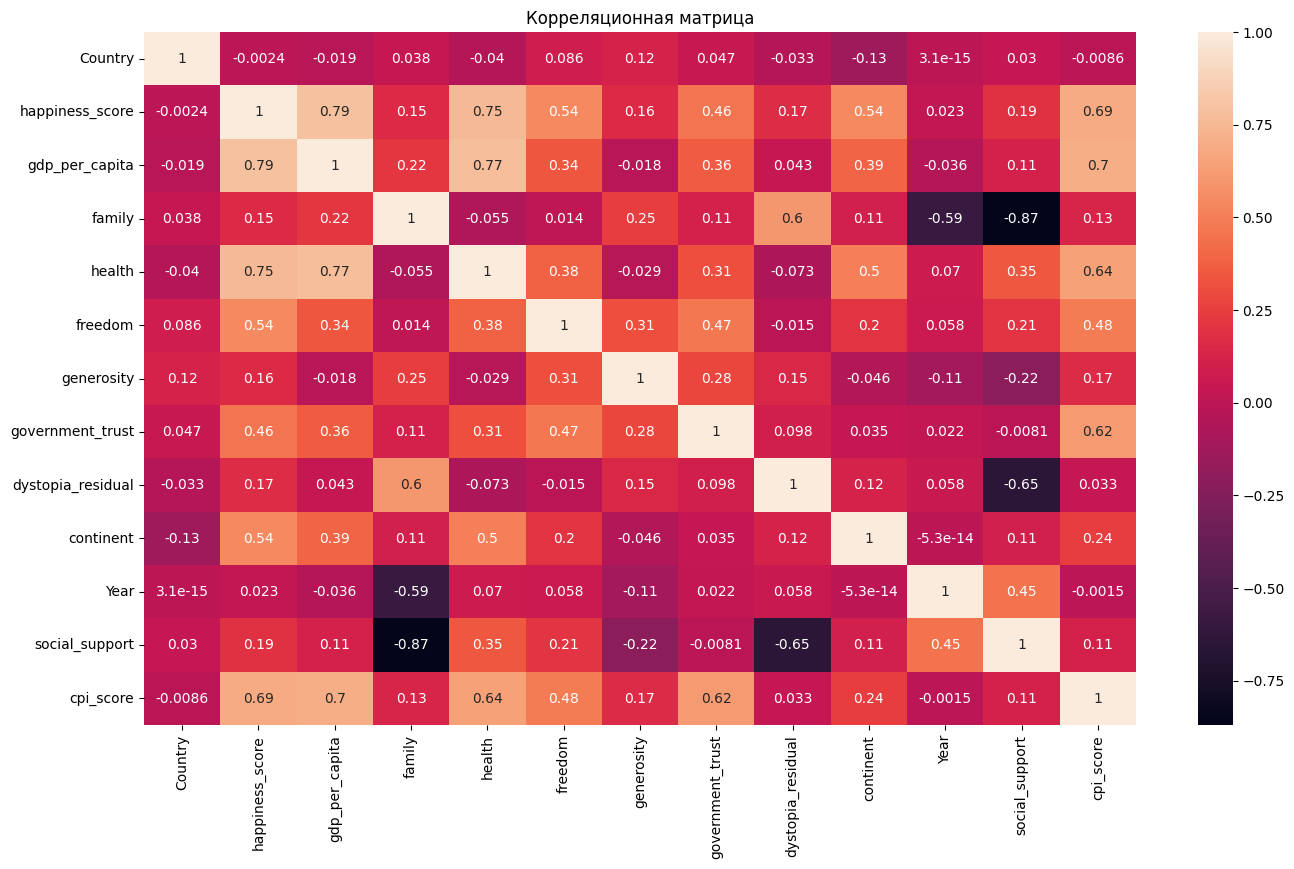

In [ ]:
plt.figure(figsize=(16, 9))
sns.heatmap(data_numeric.corr(), annot = True)
plt.title('Корреляционная матрица')

# Задание 2
Продолжаем изучать цены на газ в Южной Корее. Файл с данными “gas_sales_data.csv” вы сможете найти в материалах занятия (для этого набора данных вы ранее рассчитывали коэффициенты корреляции в тренажере).

В этом задании нужно окончательно ответить на вопрос:
Есть ли связь между среднемесячной температурой и потреблением газа в Южной Корее?

Для этого:

* Оставьте только два столбца:'Temperature' и 'Sum'.
* Постройте диаграмму рассеяния.
* Постройте модель линейной регрессии для выбранных признаков.
* Рассчитайте точность модели на тестовой выборке.
* Выведите график остатков.

In [ ]:
df = pd.read_csv('/content/gas_sales_data.csv')
df_cut = df[['Temperature', 'Sum']]

In [ ]:
df_cut.head()

,Temperature,Sum
0,-1.20,1717175
1,-0.99,1766341
2,6.64,1490537
3,12.11,1096964
4,17.59,790248


Text(0.5, 1.0, 'Взаимосвязь между среднемесячной температурой и потреблением газа')

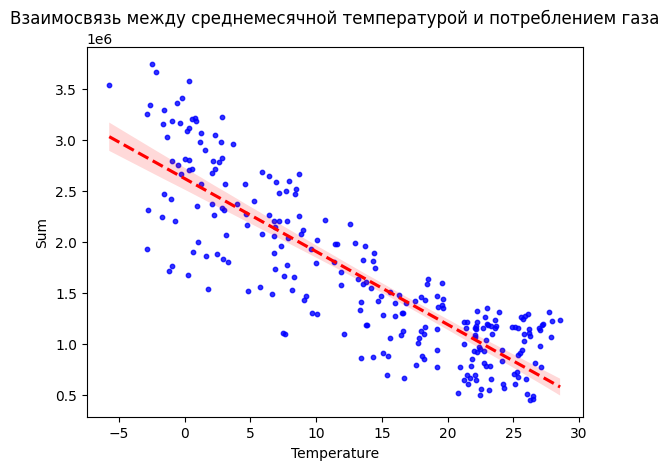

In [ ]:
sns.regplot(
    data=df_cut, x='Temperature', y='Sum',
    line_kws={'color': 'red', 'linestyle': '--'},  # Настройка линии
    scatter_kws={'color': 'blue', 's': 10},       # Настройка точек
    ci=95                                         # 95% доверительный интервал
)
plt.title('Взаимосвязь между среднемесячной температурой и потреблением газа')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Разбиваем данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(df_cut['Temperature'].values.reshape(-1, 1)
                                                    , df_cut['Sum'], test_size=0.3)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Предсказание на тестовых данных
y_pred = model.predict(X_test)

# Оценка модели
from sklearn.metrics import r2_score, root_mean_squared_error
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"R^2 score: {r2}")
print(f'RMSE: {rmse}')

R^2 score: 0.743653990051572
RMSE: 431631.7659735934


Text(0.5, 1.0, 'Распределение остатков')

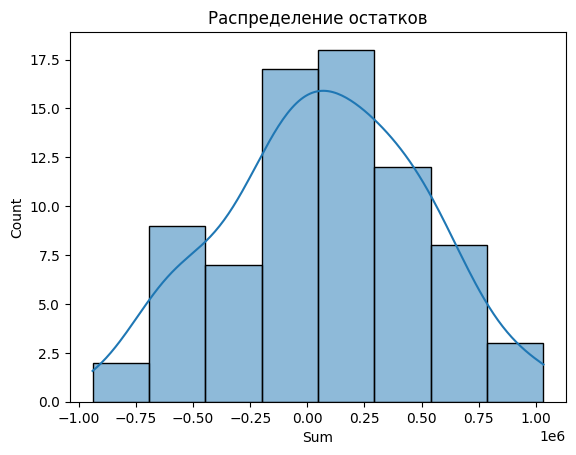

In [ ]:
# Распределение остатков
sns.histplot(y_test - y_pred.reshape((76,)), kde=True)
plt.title('Распределение остатков')

Рапсределение остатков близко к нормальному, что свидетельствует о хорошем качестве модели